## Loading Packages, Functions and Data

In [1]:
# import custom functions and required packages from secondary file
from project_functions import *
# turn off warnings
warnings.filterwarnings("ignore")

In [2]:
# Runtime: ~ 3 minutes 
# path to downloaded all match data [UPDATE AS REQUIRED]
path = "/Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/"
game_ids = ["COM-000001_DFL-MAT-J03WMX", "COM-000001_DFL-MAT-J03WN1",
            "COM-000002_DFL-MAT-J03WPY", "COM-000002_DFL-MAT-J03WOH",
            "COM-000002_DFL-MAT-J03WQQ", "COM-000002_DFL-MAT-J03WOY",
            "COM-000002_DFL-MAT-J03WR9"]
# create dictionary of all 7 game objects
game_data = {}
for id in game_ids:
    game = import_match_data(id, path)
    game_data.update({id: game})

Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WMX.xml

100%|██████████| 7590415/7590415 [00:10<00:00, 735757.14it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml

100%|██████████| 7099405/7099405 [00:08<00:00, 871779.50it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WPY.xml

...

100%|██████████| 6442009/6442009 [00:09<00:00, 688530.69it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOY.xml

100%|██████████| 6556773/6556773 [00:11<00:00, 576173.99it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WR9.xml

100%|██████████| 6753373/6753373 [00:08<00:00, 809467.54it/s] 


In [3]:
import pickle
pass_event_consol = pickle.load(open('consol.pkl', 'rb'))

# column dictionary for plotting and tables
column_dict = {'outp2inp':"OP2IP", 'd2co_ts_max_dec':"$\\text{CO}_{\\text{MD}}$", 'd2tloc_ts_range':"$\\text{TLoC}_{r}$", "d2co_ts_max_dec_ind":"$\\text{CO}_{\\text{MD}>0}$",
               'd2tlac_ts_range':"$\\text{TLaC}_{r}$",'d2tloc_ts_ae':"$\\text{TLoC}_{\\text{AE}}$", 'd2tlac_ts_ae':"$\\text{TLaC}_{\\text{AE}}$",
               'hp_pass':"$\\text{HP}$", 'pressure_ts_drop_time':"$\\text{P}_{\\text{DT}}$",'sa_ts_max_inc':"$\\text{SA}_{\\text{MI}}$",
               'sp_ts_max_inc':"$\\text{SP}_{\\text{MI}}$", 'sa_ts_no_inc':"$\\text{SA}_{\\text{NI}}$",
               'sp_ts_no_inc':"$\\text{SA}_{\\text{MI}}$",'one_two':"$\\text{OT}$", "hp2lp":"HP2LP"}

# metric column names
col_names = ["outp2inp", "d2co_ts_max_dec_ind", "d2co_ts_max_dec", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae", "hp2lp", 'sa_ts_no_inc', "sa_ts_max_inc",  'sp_ts_no_inc',
             "sp_ts_max_inc", "one_two"]

# remove uncertain frames (if not already removed)
pass_event_consol_is = pass_event_consol[pass_event_consol["certain"]==True]
post_pass_emb = pass_event_consol_is[col_names]
post_pass_emb

# binary variable columns
bin_cols = ["outp2inp", "d2co_ts_max_dec_ind", "h2lp",'sa_ts_no_inc', 'sp_ts_no_inc', "one_two"]
# continuous variable columns
cont_cols = ["d2co_ts_max_dec", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae",
             "sa_ts_max_inc", "sp_ts_max_inc"]
# role dictionary
role_dict = {"goalkeeper": "Goalkeeper", "defender": "Defender", "midfielder":"Midfielder", "forward":"Forward"}

## Out-of-Position Plots

I analyze the fitted bivariate normal models, in particular;
* the variances in each direction
* distances between the means

In [4]:
# means
mle_means = pass_event_consol_is["5m_mle"].map(lambda x: x[0])
mcd_means = pass_event_consol_is["5m_mcd"].map(lambda x: x[0])

# variances in each direction
mle_var_x = pass_event_consol_is["5m_mle"].map(lambda x: np.sqrt(x[1][0,0]))
mle_var_y = pass_event_consol_is["5m_mle"].map(lambda x: np.sqrt(x[1][1,1]))
mcd_var_x = pass_event_consol_is["5m_mcd"].map(lambda x: np.sqrt(x[1][0,0]))
mcd_var_y = pass_event_consol_is["5m_mcd"].map(lambda x: np.sqrt(x[1][1,1]))

# differences in means
mle_mcd_diff_mean = (mcd_means - mle_means).map(np.linalg.norm).values
mle_mcd_diff_mean_x = (mcd_means - mle_means).map(lambda x: abs(x[0])).values
mle_mcd_diff_mean_y = (mcd_means - mle_means).map(lambda x: abs(x[1])).values

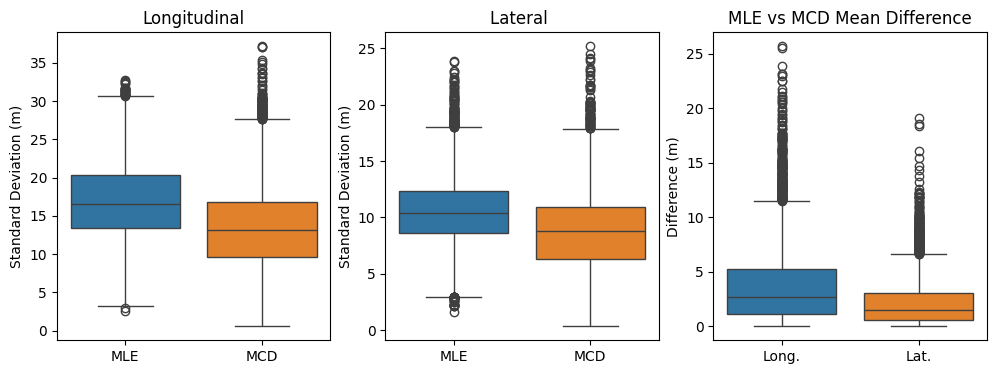

In [5]:
# compare standard deviation
# longitudinal
fig, ax = plt.subplots(1, 3, figsize=(12,4))
sns.boxplot([mle_var_x, mcd_var_x], ax=ax[0])
ax[0].set_xticks([0, 1], ['MLE', 'MCD'])
ax[0].set_title("Longitudinal")
ax[0].set_ylabel("Standard Deviation (m)")

# lateral
sns.boxplot([mle_var_y, mcd_var_y], ax=ax[1])
ax[1].set_xticks([0, 1], ['MLE', 'MCD'])
ax[1].set_ylabel("Standard Deviation (m)")
ax[1].set_title("Lateral ")

# comparing differences in mean
sns.boxplot([mle_mcd_diff_mean_x, mle_mcd_diff_mean_y], ax=ax[2])
ax[2].set_title("MLE vs MCD Mean Difference")
ax[2].set_xticks([0, 1], ['Long.', 'Lat.'])
ax[2].set_ylabel("Difference (m)")
plt.show()

In [6]:
# summary stats of plots above
arrays = [mle_var_x , mle_var_y , mcd_var_x , mcd_var_y, mle_mcd_diff_mean_x, mle_mcd_diff_mean_y]
names = ["SDx(MLE)", "SDy(MLE)", "SDx(MCD)", "SDY(MCD)", "Dx", "Dy"]
summary = pd.DataFrame({
    "N": [len(x) for x in arrays],
    "Mean": [np.mean(x) for x in arrays],
    "Std": [np.std(x, ddof=1) for x in arrays],
    "Min": [np.min(x) for x in arrays],
    "25%": [np.percentile(x, 25) for x in arrays],
    "Median": [np.median(x) for x in arrays],
    "75%": [np.percentile(x, 75) for x in arrays],
    "Max": [np.max(x) for x in arrays],
}, index=names)
summary

,N,Mean,Std,Min,25%,Median,75%,Max
SDx(MLE),5607,16.907774,5.282278,2.577989,13.467406,16.506971,20.343095,32.805602
SDy(MLE),5607,10.456452,3.302452,1.632757,8.609058,10.393200,12.376667,23.845747
SDx(MCD),5607,13.588730,5.509815,0.583110,9.644341,13.146564,16.856615,37.151626
SDY(MCD),5607,8.753087,3.648391,0.327766,6.309221,8.775867,10.943245,25.176855
Dx,5607,3.790926,3.632425,0.000614,1.133667,2.720021,5.276171,25.674262
Dy,5607,2.169092,2.155546,0.000090,0.595938,1.509191,3.017840,19.119187


### Visual Analysis

In [7]:
from matplotlib.patches import Ellipse

def get_pos_5_min(game, player, frame):
        """Get players  position for 2.5 minutes either side of a given frame."""
        alive = game.tracking_data.loc[frame-3750 : frame+3750]
        alive = np.array([alive[f"{player}_x"].values, alive[f"{player}_y"].values]).T
        alive = alive[~np.isnan(alive).any(axis=1)]
        return alive

def out_of_pos_plot(pass_row):
    """Function to plot out-of-position overview plots."""
    
    game = game_data[pass_row["match"]]
    pid = game.player_id_to_column_id(pass_row["player_id"])
    # plot pitch
    fig, ax = plot_soccer_pitch(field_dimen=game.pitch_dimensions, pitch_color="white")
    # obtain 5 minute trajectory
    track_data = get_pos_5_min(game, pid , pass_row["tracking_frame"])
    # density plot of trajectory
    sns.kdeplot(x=track_data[:,0], y=track_data[:,1], fill=True, color="SkyBlue")
    # plot trajectory
    plt.plot(track_data[:,0], track_data[:,1], color="Black", linestyle="dashed", label="Passer Trajectory")
    
    
    # plot post-pass trajectory
    plt.plot(pass_row["post_pass_5"][:,0], pass_row["post_pass_5"][:,1], color="orange", label="Post-Pass Trajectory", linewidth=2)
    plt.scatter(x=pass_row["post_pass_5"][0][0], y=pass_row["post_pass_5"][0][1], color="orange", zorder=3, marker="s", label="Start", s=70)
    plt.scatter(x=pass_row["post_pass_5"][-1][0], y=pass_row["post_pass_5"][-1][1], color="orange", zorder=3, label="End", s=70)

    ## MLE Ellipse
    
    # obtain bi-variate normal MLE parameters
    mu, Sigma = pass_row["5m_mle"]

    # Chi-square value for 80% confidence (2 degrees of freedom)
    chi2_val = stats.chi2.ppf(0.80, df=2)

    # Eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Ellipse parameters
    width = 2 * np.sqrt(eigvals[0] * chi2_val)
    height = 2 * np.sqrt(eigvals[1] * chi2_val)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    ellipse = Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=angle,
        edgecolor='red',
        facecolor='none',
        linewidth=2,
        label='80% CI (MLE)'
    )
    ax.add_patch(ellipse)
    
    ## MCD Ellipse
    
    # obtain bi-variate normal MCD parameters
    mu, Sigma = pass_row["5m_mcd"]

    # Chi-square value for 80% confidence (2 degrees of freedom)
    chi2_val = stats.chi2.ppf(0.95, df=2)

    # Eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Ellipse parameters
    width = 2 * np.sqrt(eigvals[0] * chi2_val)
    height = 2 * np.sqrt(eigvals[1] * chi2_val)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    ellipse = Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=angle,
        edgecolor='blue',
        facecolor='none',
        linewidth=2,
        label='95% CI (MCD)'
    )
    ax.add_patch(ellipse)
    
    
    team_side_dict = {"home":"Home", "away":"Away"}
    plt.legend(loc="upper left")
    # add title detailing player position and team
    plt.title(f"Position: {role_dict[pass_row["role"]]}, Team: {team_side_dict[pass_row["team_side"]]} ")
    # add arrow indicating direction of play
    plt.annotate(
    "Attacking Direction",
    xy=(0.95, 1.025),       # arrow end
    xytext=(0.7,1.025),   # arrow start
    xycoords="axes fraction",
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle=f"{"->" if pass_row["team_side"] == "home" else "<-"}", lw=2),
    ha="left",
    va="center")
    plt.show()

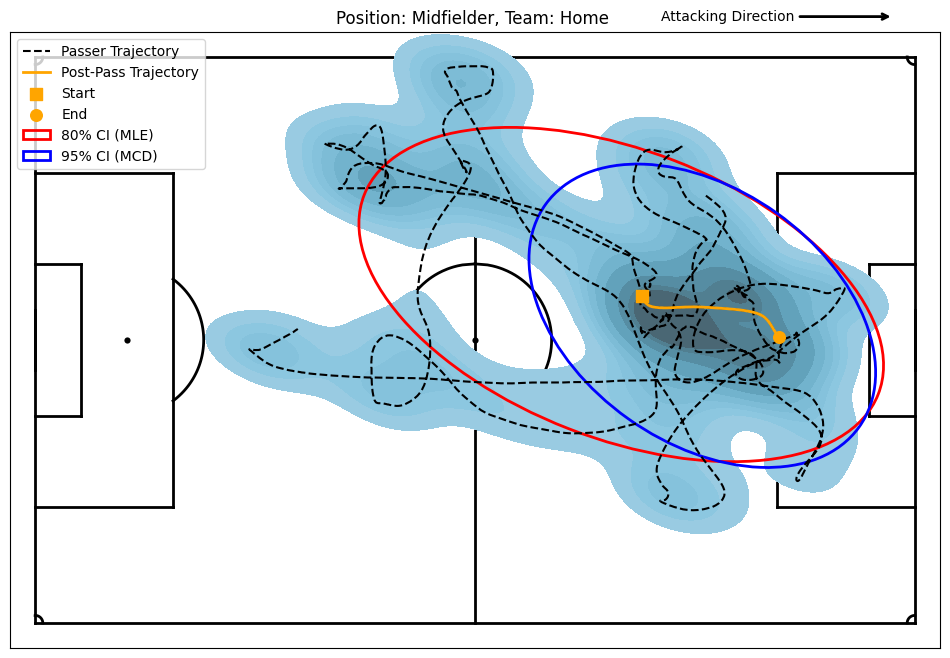

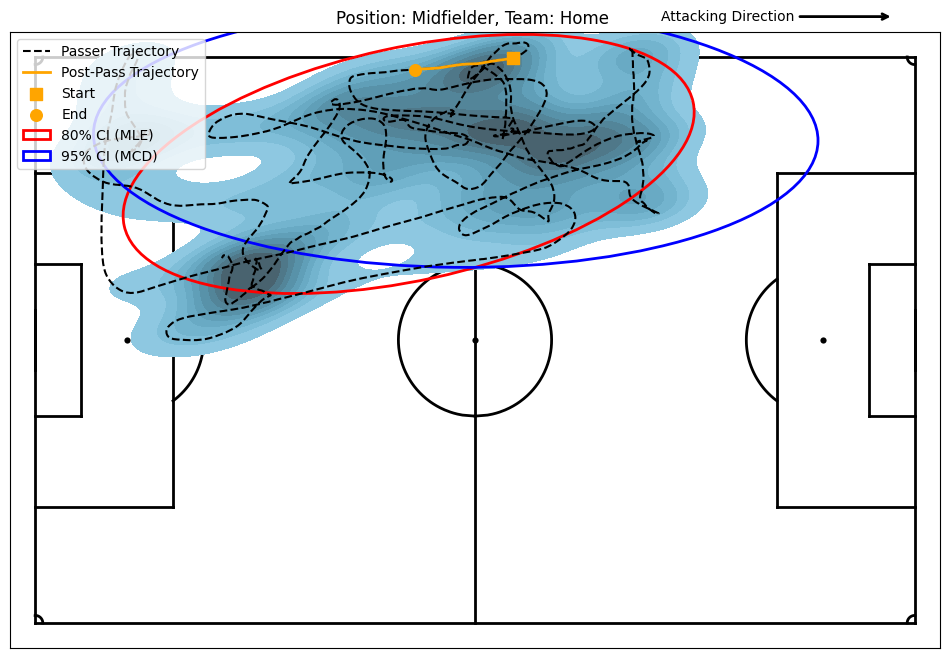

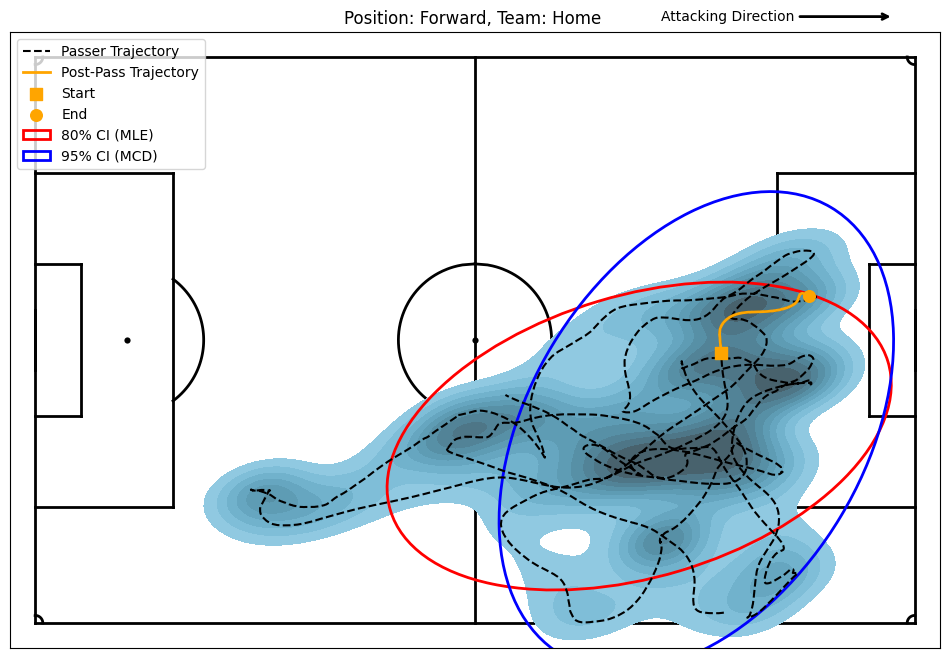

In [8]:
# plot random passes (note: third plot included in report)
np.random.seed(123)
rand_pass = np.random.randint(len(pass_event_consol), size=3)
for i in rand_pass:
    out_of_pos_plot(pass_event_consol[pass_event_consol["level_0"]==i].iloc[0])

### Out-of-Position Pass Analysis

In [9]:
print("No. out of position passes:", np.sum(pass_event_consol_is["out_of_position_s"]))
print("% Passes Out-of-Position:", np.mean(pass_event_consol_is["out_of_position_s"]))

No. out of position passes: 1586
% Passes Out-of-Position: 0.28286070982700195


How many out-of-position passes do players make? Set-piece Events should be out-of-position [APPENDIX Analysis]

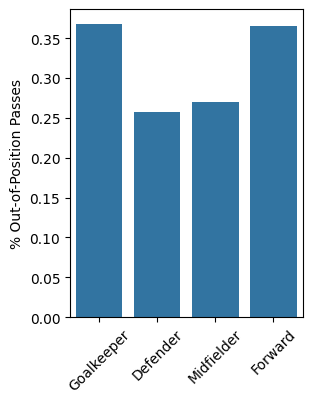

In [10]:
role_order = ["goalkeeper", "defender", "midfielder", "forward"]
role_labels = ["Goalkeeper", "Defender", "Midfielder", "Forward"]
plt.figure(figsize=(3,4))
sns.barplot(pass_event_consol_is.groupby(["role"])["out_of_position_s"].mean(),
            order = role_order)
plt.ylabel("% Out-of-Position Passes"); plt.xlabel("")
plt.xticks(rotation = 45)
plt.xticks(
    ticks=range(4),
    labels=role_labels
)
plt.show()


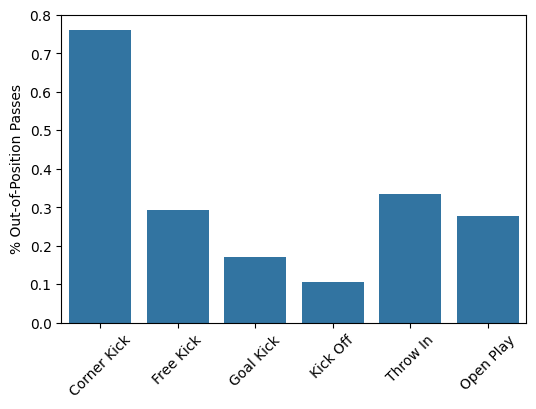

In [11]:
# set_piece
role_order = ["corner_kick", "free_kick", "goal_kick", "kick_off", "throw_in", "no_set_piece"]
sp_labels = ["Corner Kick", "Free Kick", "Goal Kick", "Kick Off", "Throw In", "Open Play"]
plt.figure(figsize=(6,4))
sns.barplot(pass_event_consol_is.groupby(["set_piece"])["out_of_position_s"].mean(),
            order=role_order)
plt.xticks(ticks=range(6),labels=sp_labels)
plt.ylabel("% Out-of-Position Passes"); plt.xlabel("")
plt.xticks(rotation = 45)
plt.show()

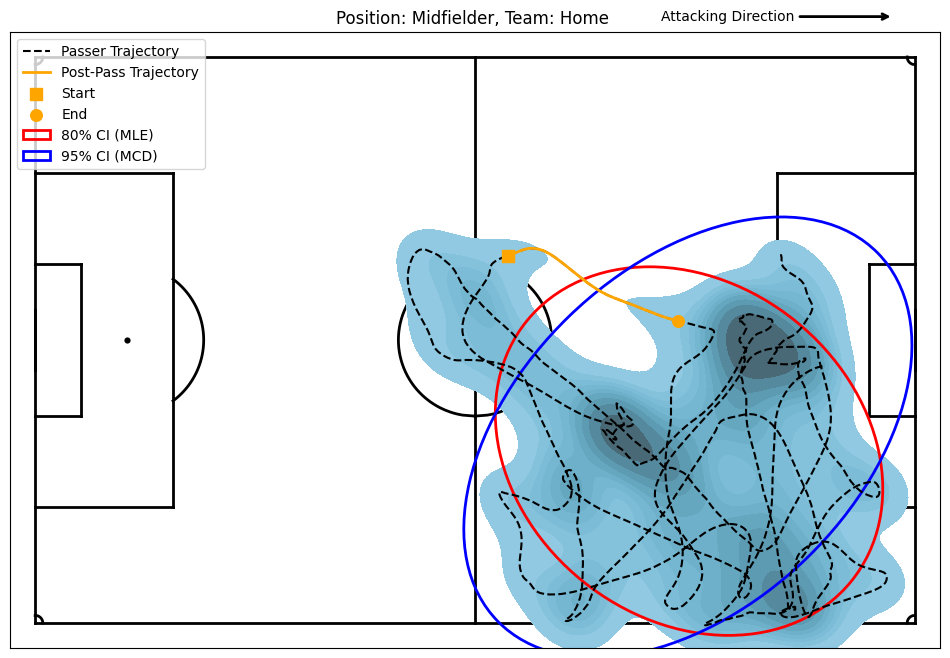

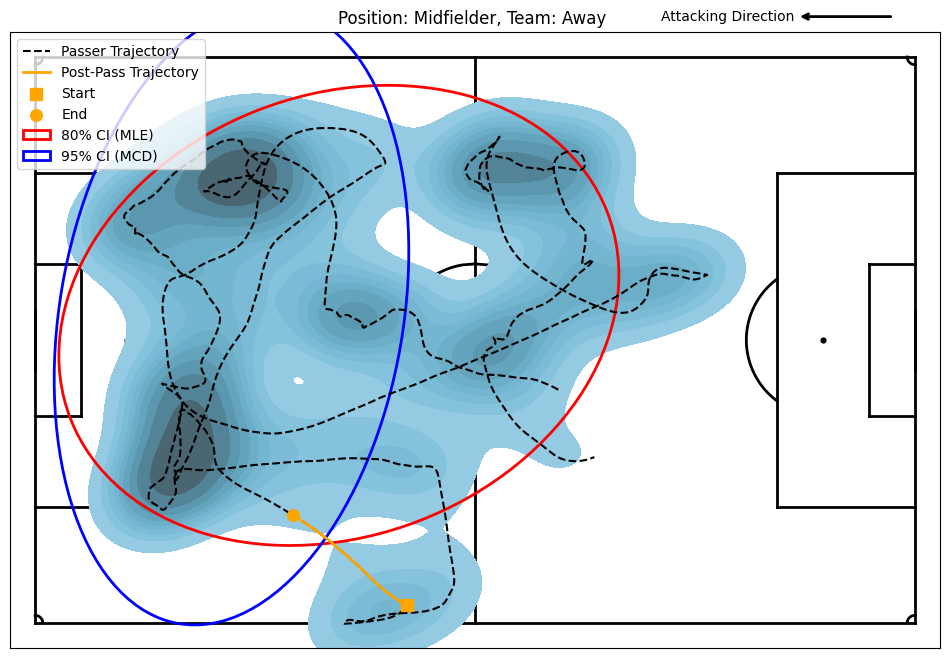

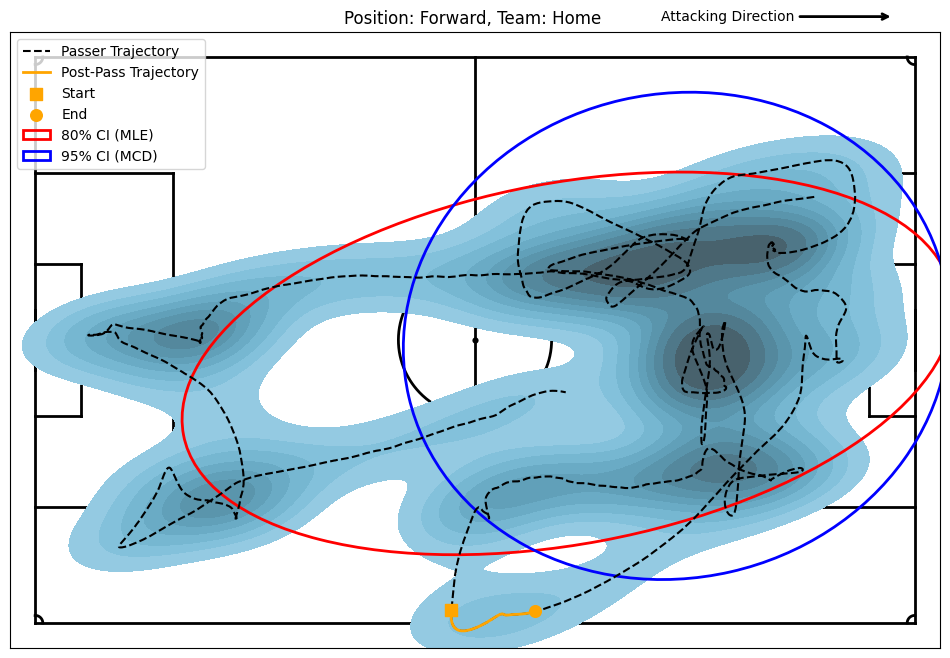

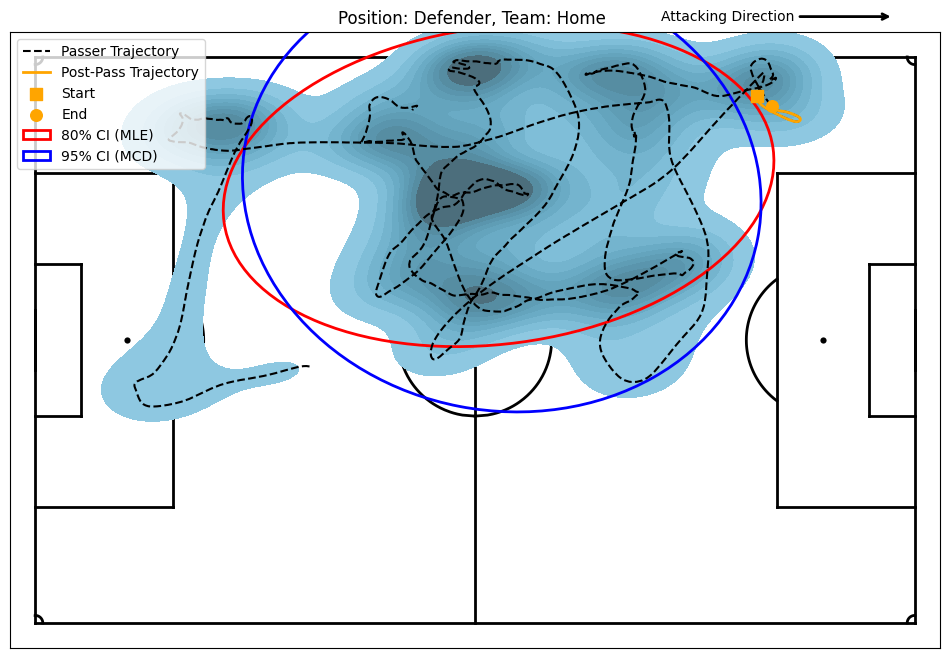

In [12]:
# plot 4 example of out-of-position

# random passes
np.random.seed(1235)
out_to_in = pass_event_consol_is[(pass_event_consol_is["out_of_position_s"]==True)&(pass_event_consol_is["out_of_position_e"]==False)].sample(2)
out_to_out = pass_event_consol_is[(pass_event_consol_is["out_of_position_s"]==True)&(pass_event_consol_is["out_of_position_e"]==True)].sample(2)
for i in range(2) :
    out_of_pos_plot(out_to_in.iloc[i])
for i in range(2):
    out_of_pos_plot(out_to_out.iloc[i])

## Player moves to an opponent

In [13]:
pass_event_consol_is["m2o"].value_counts()/len(pass_event_consol_is["m2o"])

m2o
False    0.918316
True     0.081684
Name: count, dtype: float64

In [14]:
def plot_event(game, frames, passers=None, passer_traj=None, frame_time=False, centroid=None):
    """Function to plot event frame(s) within game.
    Input:
        game (Game): game
        frame (int): index of frame to plot
    """
    
    x_grid, _ = np.meshgrid(np.linspace(0, 1, 15), np.linspace(0, 1, 10))
    n = len(frames)
    fig, ax = plt.subplots(1, n, figsize=(15, 3.26))
    for i in range(n):
        fig, ax[i] = plot_soccer_pitch(field_dimen=game.pitch_dimensions, pitch_color="white",
                                       
                                       fig=fig, ax=ax[i])
        fig, ax[i] = plot_tracking_data(game,
                                    frames[i],
                                    fig=fig,
                                    ax=ax[i],
                                    variable_of_interest=game.tracking_data.loc[frames[i], "frame"],
                                    )
        
        # plot location of passer
        if passers is not None:
            passer_num = game.player_id_to_column_id(passers[i])
            ax[i].plot(game.tracking_data.iloc[frames[i],:][passer_num+"_x"],
                                   game.tracking_data.iloc[frames[i], :][passer_num+"_y"],
                                   markerfacecolor="yellow", 
                                   marker="o", markersize=10, markeredgecolor=("green" if passer_num[:4]=="home" else "red"), zorder=3,
                                   markeredgewidth =1.5)
        if (passer_traj is not None) & (i>0):
            ax[i].plot(passer_traj[:(frames[i]-frames[0]),0],passer_traj[:(frames[i]-frames[0]),1],
                       c="black", linestyle="dashed")
        for text in ax[i].texts:
            text.set_visible(False)
            
        if frame_time:
                    ax[i].text(0.98, 1.05, f"Post-Pass Time: {(frames[i]-frames[0])*1/25:.2f} Seconds",transform=ax[i].transAxes,ha="right", va="top")
        if centroid is not None:
            ax[i].vlines(centroid[0,frames[i]-frames[0]], ymin=-34, ymax=34, colors= "tab:orange",linestyles="dashed", lw=2)

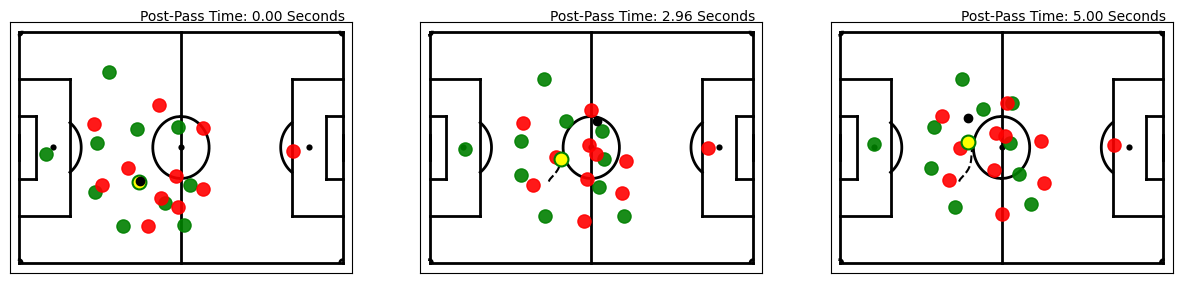

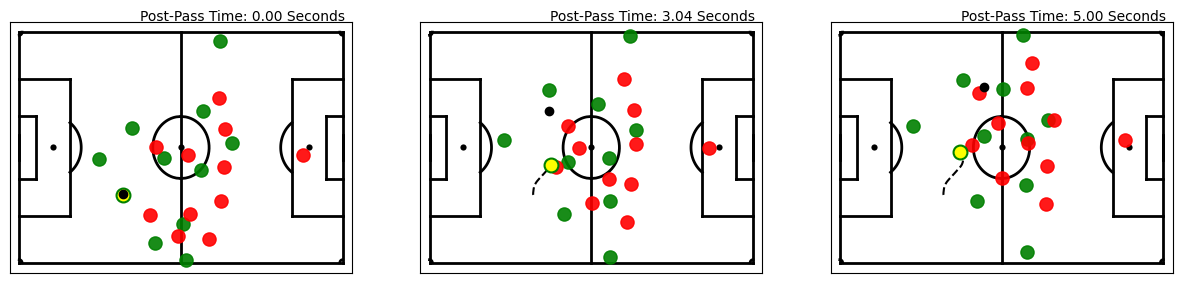

In [15]:
# plot example with top bucket of co and top bucket of distance travelled and arrived at opponent
sample_row_co = pass_event_consol_is[pass_event_consol_is["m2o"]==True].sample(2, random_state=1)
for i in range(2):
    game = game_data[sample_row_co.iloc[i]["match"]]
    frame_id = sample_row_co.iloc[i]["tracking_frame"]
    frame_min = np.argmin(sample_row_co.iloc[i]["d2co_ts"])
    plot_event(game, [frame_id, frame_id +frame_min , frame_id+125],
               passers=[sample_row_co.iloc[i]["player_id"], sample_row_co.iloc[i]["player_id"], sample_row_co.iloc[i]["player_id"]],
               passer_traj=sample_row_co.iloc[i]["post_pass_5"],
               frame_time=True)

## Manoeuvering

In [16]:
def get_team_centroid(match, first_frame, last_frame, team="home", exclude_goalkeeper=True):
    """Function to calculate centroid of a team at a given frame."""
    game = game_data[match]
    player_ids = game.get_column_ids(team=team, idx=first_frame)
    if exclude_goalkeeper:
        players_df = game.home_players if team == "home" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[first_frame:last_frame+1, :]
    coords = np.array([
        [frame[f"{pid}_x"], frame[f"{pid}_y"]]
        for pid in player_ids
    ], dtype=float)
    
    # coords = coords[~np.isnan(coords).any(axis=(1,2))]
    
    return np.nanmean(coords,axis=0)

### Spread based analysis 

0.9 Quantile: 9.919800000000002
0.1 Quantile: 1.734200000000001


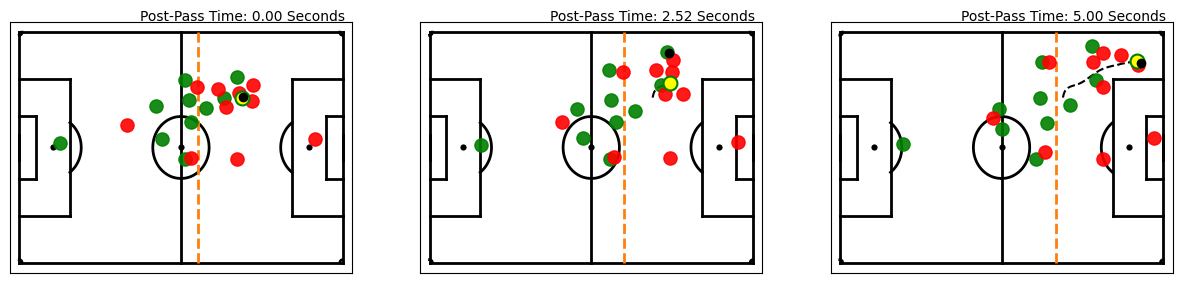

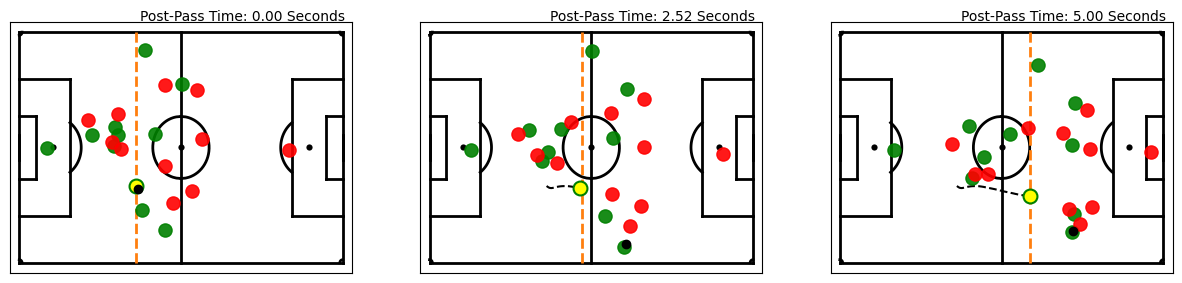

In [17]:
# top 10% quantile
lo_range_90 = np.quantile(pass_event_consol_is["d2tloc_ts_range"], 0.9)
print("0.9 Quantile:", lo_range_90)
# bottom 10% quantile
lo_range_10 = np.quantile(pass_event_consol_is["d2tloc_ts_range"], 0.1)
print("0.1 Quantile:", lo_range_10)
# random pass with range in top 10%
lo_90_sample = pass_event_consol_is[pass_event_consol_is["d2tloc_ts_range"]>lo_range_90].sample(n=1, random_state=12345).iloc[0]
# random pass with range in bottom 10%
lo_10_sample = pass_event_consol_is[pass_event_consol_is["d2tloc_ts_range"]<lo_range_10].sample(n=1, random_state=1234).iloc[0]
# plot the sampled passes
plot_event(game_data[lo_90_sample["match"]], [lo_90_sample["tracking_frame"], lo_90_sample["tracking_frame"] + 63 , lo_90_sample["tracking_frame"] + 125],
           passers=[lo_90_sample["player_id"],lo_90_sample["player_id"],lo_90_sample["player_id"]],
           passer_traj=lo_90_sample["post_pass_5"],
           frame_time=True,
           centroid=get_team_centroid(lo_90_sample["match"], lo_90_sample["tracking_frame"],  lo_90_sample["tracking_frame"] + 125,team= lo_90_sample["team_side"]))

plot_event(game_data[lo_10_sample["match"]], [lo_10_sample["tracking_frame"], lo_10_sample["tracking_frame"] + 63 , lo_10_sample["tracking_frame"] + 125],
           passers=[lo_10_sample["player_id"],lo_10_sample["player_id"],lo_10_sample["player_id"]],
           passer_traj=lo_10_sample["post_pass_5"],
           frame_time=True,
           centroid=get_team_centroid(lo_10_sample["match"], lo_10_sample["tracking_frame"],  lo_10_sample["tracking_frame"] + 125,team= lo_10_sample["team_side"]))

### Regularity Based Measure

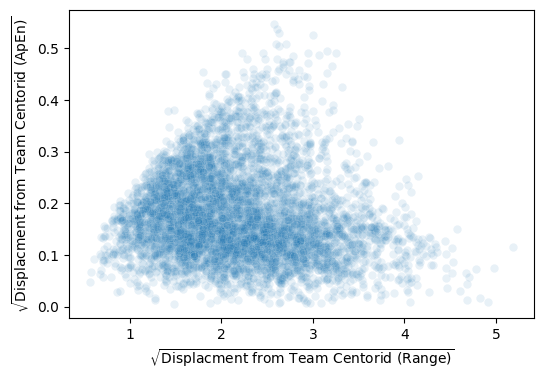

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=np.sqrt(pass_event_consol_is["d2tloc_ts_range"]),
            y = np.sqrt(pass_event_consol_is["d2tloc_ts_ae"]),
            alpha=0.1)
plt.xlabel("$\\sqrt{\\text{Displacment from Team Centorid (Range)}}$")
plt.ylabel("$\\sqrt{\\text{Displacment from Team Centorid (ApEn)}}$")
plt.show()

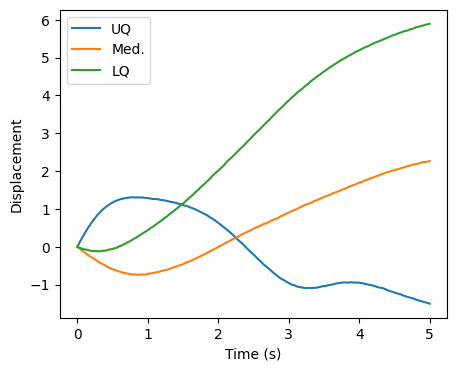

In [19]:
lo_range_lq = np.quantile(pass_event_consol_is["d2tloc_ts_range"], 0.25)
lo_range_uq = np.quantile(pass_event_consol_is["d2tloc_ts_range"], 0.75)

# filter IQR of range
ae_iqr = pass_event_consol_is[(pass_event_consol_is["d2tloc_ts_range"]>lo_range_lq)&(pass_event_consol_is["d2tloc_ts_range"]<lo_range_uq)]

fig = plt.figure(figsize= (5,4))

# AE UQ
ae_uq_row = ae_iqr[ae_iqr["d2tloc_ts_ae"] == np.quantile(ae_iqr["d2tloc_ts_ae"],0.75, method="lower")]
plt.plot(np.linspace(0,5,126),ae_uq_row["d2tloc_ts"].iloc[0] - ae_uq_row["d2tloc_ts"].iloc[0][0], label = "UQ")

# AE Median 
ae_med_row = ae_iqr[ae_iqr["d2tloc_ts_ae"] == np.quantile(ae_iqr["d2tloc_ts_ae"],0.5, method="lower")]
plt.plot(np.linspace(0,5,126), ae_med_row["d2tloc_ts"].iloc[0] - ae_med_row["d2tloc_ts"].iloc[0][0], label = "Med.")

# AE LQ
ae_lq_row = ae_iqr[ae_iqr["d2tloc_ts_ae"] == np.quantile(ae_iqr["d2tloc_ts_ae"],0.25, method="lower")]

# plot the time series
plt.plot(np.linspace(0,5,126),ae_lq_row["d2tloc_ts"].iloc[0] - ae_lq_row["d2tloc_ts"].iloc[0][0], label = "LQ")
plt.xlabel("Time (s)"); plt.ylabel("Displacement")
plt.legend(); plt.show()